# Exploratory data analysis

In [1]:
import pandas as pd

In [2]:
data_path = "data/after_preprocessing/995k_rows_cleaned.csv"
df = pd.read_csv(data_path)
df.head(3)

,id,domain,type,url,content,title
0,7444726.0,nationalreview.com,political,http://www.nationalreview.com/node/152734/%E2%...,plus one article on google plus (thanks to ali...,iran news round up
1,6213642.0,beforeitsnews.com,fake,http://beforeitsnews.com/economy/2012/06/the-c...,the cost of the best senate banking committee ...,the cost of the best senate banking committee ...
2,3867639.0,dailycurrant.com,satire,http://dailycurrant.com/2016/01/18/man-awoken-...,man awoken from <NUM>-year coma commits suicid...,man awoken from <NUM>-year coma commits suicid...


## Average document sparsity
We will be computing how much of the actual vocabulary is used in an average document.

We will do so by sampling a representative number of documents from the cleaned corpus and counting the average number of unique tokens in them.

## Type distribution
We will analyze the distribution of the ```type```-column using a pie chart

In [3]:
type_col = df["type"]
type_col.unique()

array(['political', 'fake', 'satire', 'reliable', 'conspiracy',
       'unreliable', 'bias', 'rumor', 'clickbait', 'hate', 'junksci'],
      dtype=object)

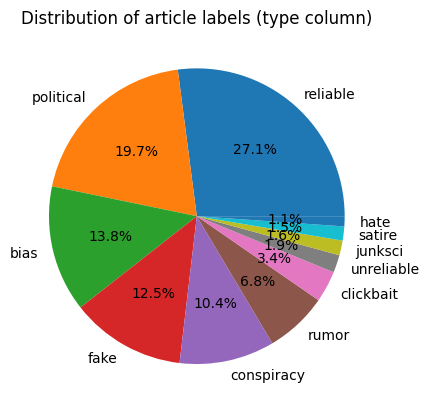

In [4]:
import matplotlib.pyplot as plt

counts = type_col.value_counts()
counts.plot(kind="pie", autopct='%1.1f%%')
plt.title("Distribution of article labels (type column)")
plt.ylabel("")
plt.show()

It is clear that these labels are somewhat continuous, and from [Fake News Corpus](https://github.com/several27/FakeNewsCorpus), we can arrange them the following way, from most to least credible:
1. reliable
2. political
3. unreliable
4. clickbait
5. hate
6. junksci
7. conspiracy
8. bias
9. satire
10. fake


Clickbait is defined as ```Sources that provide generally credible content, but use exaggerated, misleading, or questionable headlines, social media descriptions, and/or images.```. Since it contains generally real information, we will set this at the point of differentiation for binary classification.

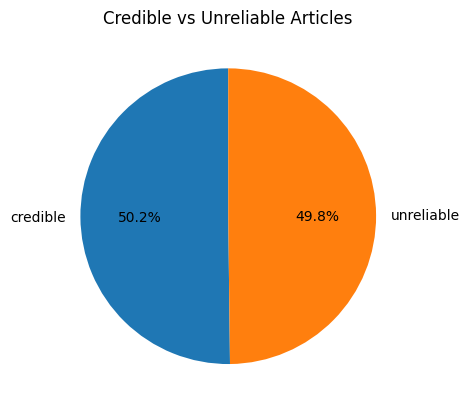

In [5]:
true_labels = ["reliable", "political", "clickbait"]
grouped = type_col.apply(lambda x: "credible" if x in true_labels else "unreliable")
counts = grouped.value_counts()
counts.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Credible vs Unreliable Articles")
plt.ylabel("")
plt.show()

## Sources
We will analyze how the articles are distributed among the sources. This will uncover information about potential dominating sources etc..

Additionally, for each source/bar in the plot, we will colour code it into the different values of the ```type``` column in order to gain insights into how the type-values are distributed among the sources.

In [31]:
domains = df['domain'].unique()

top_20 = df["domain"].value_counts().head(20)
top_10 = top_20.head(10)

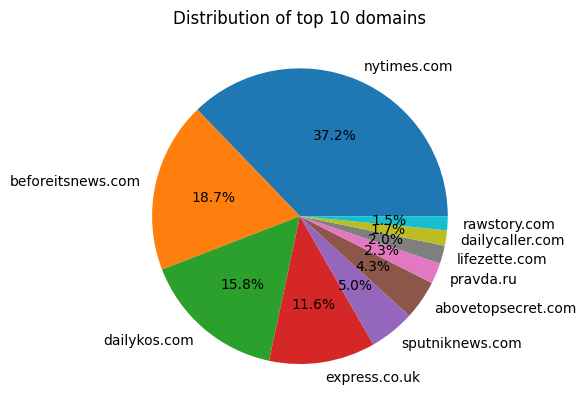

In [32]:
top_10.plot(kind="pie", autopct='%1.1f%%')
plt.title("Distribution of top 10 domains")
plt.ylabel("")
plt.show()

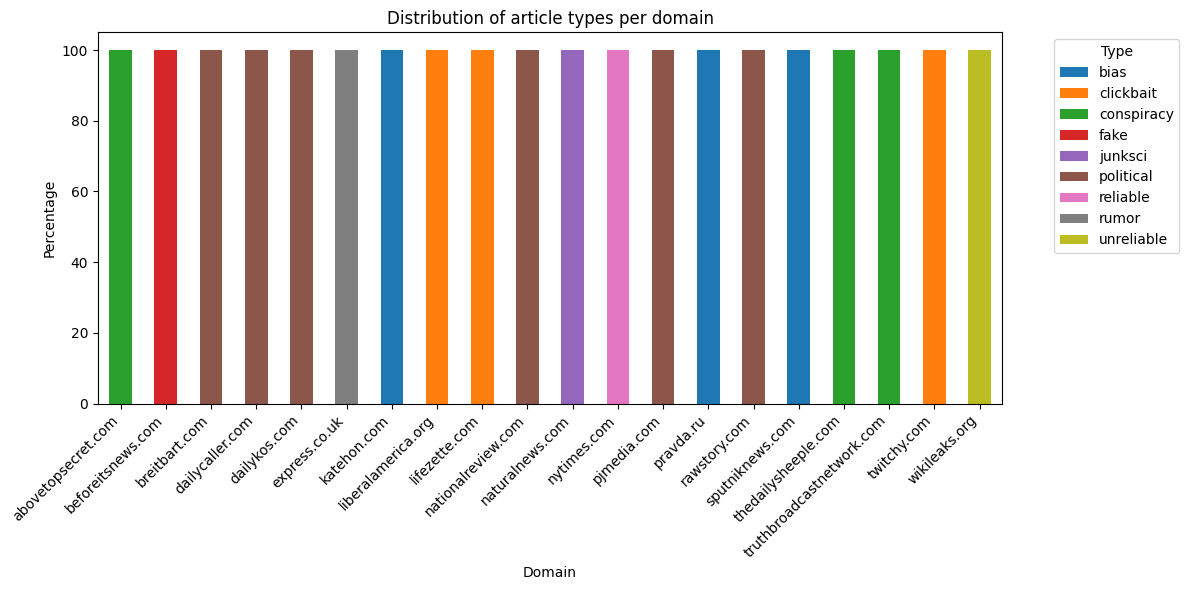

In [39]:
top_20_domains = df[df["domain"].isin(top_20.index)]
counts = (
    top_20_domains.groupby(["domain", "type"])
          .size()
          .unstack(fill_value=0)
)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.ylabel("Percentage")
plt.xlabel("Domain")
plt.title("Distribution of article types per domain")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

It appears that each of the top 20 domains only have a single type value associated to them, meaning that the domain can carry a lot of signal about the type of an article.

## Zipf's law
We will be analyzing the different vocabularies (```nosw_nostem```, ```nostem```, both sw removal and stemming). To do this we will:
1. Compare their 100 most frequent tokens
2. Plot the frequencies of the tokens, to see if they follow a Zipfian distribution

Log-Log-diagram should appear as a straight line if the inverse-power-rule applies. That is, as seen bellow, not the case (no_stem_no_sw is close to straight).

In [8]:
from preprocessing.tokenization import *
import json

def plot_frequency_distr(tokenizer_path, mult):
    with open(tokenizer_path, "r", encoding="utf-8") as file:
        filedata = file.read()

    frequencies = json.loads(filedata)['token_frequencies']
    sort_freq = sorted(frequencies, reverse=True)

    plt.loglog(range(1000), sort_freq[4:1004])

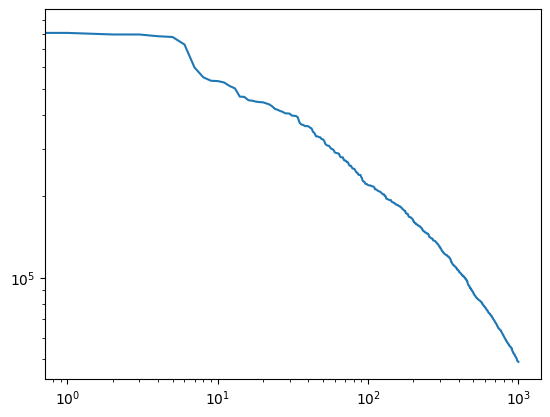

In [9]:
plot_frequency_distr(f"data/after_preprocessing/top10k_vocabulary.csv", 30)

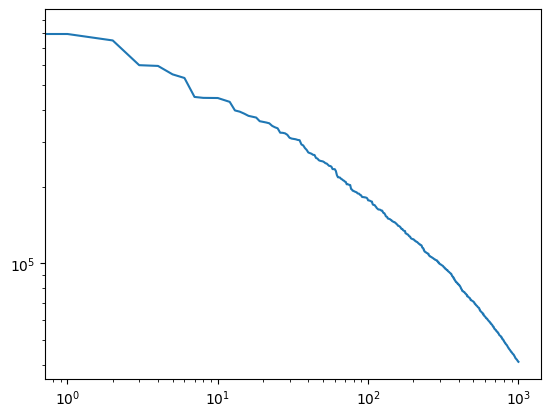

In [10]:
plot_frequency_distr(f"data/after_preprocessing/top10k_vocabulary_nostem.csv", 28)

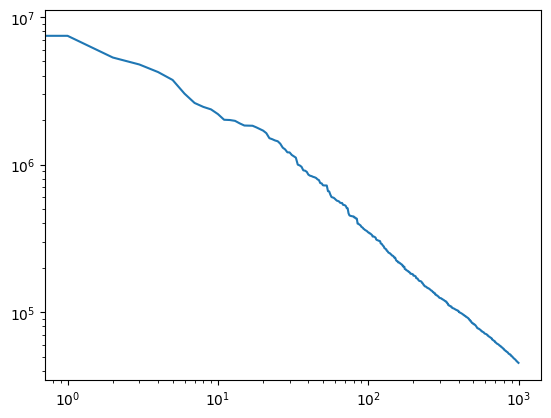

In [11]:
plot_frequency_distr(f"data/after_preprocessing/top10k_vocabulary_nostem_nosw.csv", 5)

## Article length analysis
We will sort the articles by their length (number of tokens) and plot this data with article length on the x-axis and number of articles with said length on the y-axis. It is assumed that this data will follow a normal distribution if initial sampling was perfectly random.

Additionally, we will attempt to cover any sort of correlation between an article's length and its "fakeness" score.

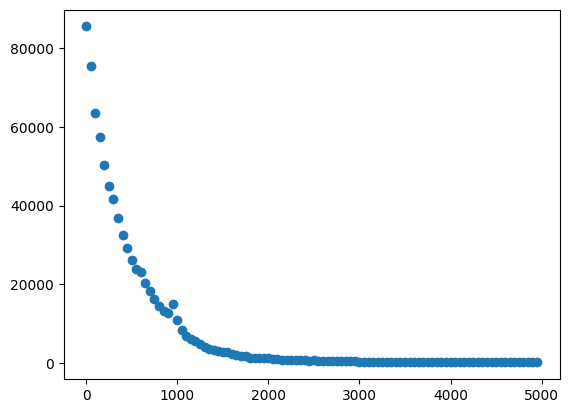

In [ ]:
sizeCounts = [0] * 100


for text in df.content:
    l = text.split(" ").__len__() // 50
    if l > 99: continue
    sizeCounts[l] += 1

plt.scatter([i * 50 for i in range(100)], sizeCounts)

# Final preprocessing step: Train/Test/Validation split
We will be splitting the dataset into 80% training data and 10% test and validation data respectively. To do so, we will be using scikit-learn to randomly split the dataset.

In [13]:
from sklearn.model_selection import train_test_split
df = pd.read_csv(data_path)

# TODO: A seed has been added for reproducibility. If you wish total randomness, set this to None
RNG_SEED = 1234
train, test = train_test_split(df, test_size=0.2, random_state=RNG_SEED)
test, val = train_test_split(test, test_size=0.5, random_state=RNG_SEED)

print("Length of train dataset: ", len(train))
print("Length of test dataset: ", len(test))
print("Length of validation dataset: ", len(val))

Length of train dataset:  634696
Length of test dataset:  79337
Length of validation dataset:  79337


In [14]:
import os
FINAL_DS_PATH = "data/final_dataset"

if not os.path.isdir(FINAL_DS_PATH):
    os.mkdir(FINAL_DS_PATH)

train.to_csv(FINAL_DS_PATH + "/train.csv", index=False)
print("Saved training dataset")

test.to_csv(FINAL_DS_PATH + "/test.csv", index=False)
print("Saved testing dataset")

val.to_csv(FINAL_DS_PATH + "/val.csv", index=False)
print("Saved validation dataset")

Saved training dataset
Saved testing dataset
Saved validation dataset


Lastly, we copy the generated vocabularies.

In [15]:
from pathlib import Path
import shutil

src = Path("data/after_preprocessing")
dest = Path("data/final_dataset")

for file in src.glob("top10k_vocabulary*.csv"):
    shutil.copy(file, dest / file.name)